<a href="https://colab.research.google.com/github/AkhileshPatidar04/Human-Activity-Recognition/blob/main/UCI%20dataset/model_3/src/model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy pandas scikit-learn torch matplotlib seaborn requests

In [ ]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

###0.  CONFIGURATION

In [ ]:
WINDOW_SIZE   = 50          # 1 second @ 50 Hz  (paper's "1 sec" setting)
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 1e-3
HIDDEN_SIZE   = 64          # BiLSTM hidden dim per direction
NUM_CLASSES   = 6
DROPOUT_RATE  = 0.25
SEED          = 42

ACTIVITIES = {
    1: "Walking", 2: "Stairs Up", 3: "Stairs Down",
    4: "Sitting",  5: "Standing",  6: "Laying"
}

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")


Using device: cuda



###1.  DATA DOWNLOAD & LOADING

In [ ]:
DATA_DIR = "UCI_HAR_Dataset"
ZIP_PATH = "UCI_HAR_Dataset.zip"
URL      = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "00240/UCI%20HAR%20Dataset.zip")

def download_dataset():
    if not os.path.exists(DATA_DIR):
        print("Downloading UCI-HAR dataset …")
        urllib.request.urlretrieve(URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(".")
        os.rename("UCI HAR Dataset", DATA_DIR)
        os.remove(ZIP_PATH)
        print("Download complete.\n")
    else:
        print("UCI-HAR dataset already present.\n")

def load_signals(split):
    """Load all 9 raw inertial signal files for train or test."""
    base   = os.path.join(DATA_DIR, split, "Inertial Signals")
    axes   = ["x", "y", "z"]
    sensors = ["body_acc", "body_gyro", "total_acc"]
    arrays  = []
    for sensor in sensors:
        for axis in axes:
            fname = f"{sensor}_{axis}_{split}.txt"
            arr   = pd.read_csv(os.path.join(base, fname),
                                delim_whitespace=True, header=None).values
            arrays.append(arr)
    # shape: (n_samples, 9_channels, 128_timesteps)
    data = np.stack(arrays, axis=1)
    return data

def load_labels(split):
    path   = os.path.join(DATA_DIR, split, f"y_{split}.txt")
    labels = pd.read_csv(path, header=None).values.flatten() - 1  # 0-indexed
    return labels

def load_uci_har():
    download_dataset()
    print("Loading signals …")
    X_train = load_signals("train")   # (7352, 9, 128)
    X_test  = load_signals("test")    # (2947, 9, 128)
    y_train = load_labels("train")
    y_test  = load_labels("test")

    # Keep only 6 channels: body_acc xyz + body_gyro xyz  (indices 0-5)
    X_train = X_train[:, :6, :WINDOW_SIZE].astype(np.float32)
    X_test  = X_test[:,  :6, :WINDOW_SIZE].astype(np.float32)

    print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
    print(f"Classes: {np.unique(y_train)}\n")
    return X_train, X_test, y_train, y_test



###DATA AUGMENTATION  (paper Section II-C-2)

In [ ]:
def rotation_matrix(axis: str, angle: float) -> np.ndarray:
    """Return 3×3 rotation matrix around x / y / z."""
    c, s = np.cos(angle), np.sin(angle)
    if axis == "x":
        return np.array([[1, 0, 0], [0, c, s], [0, -s, c]], dtype=np.float32)
    elif axis == "y":
        return np.array([[c, 0, -s], [0, 1, 0], [s, 0, c]], dtype=np.float32)
    else:                                           # z
        return np.array([[c, s, 0], [-s, c, 0], [0, 0, 1]], dtype=np.float32)

def apply_rotation(X: np.ndarray, axis: str, angle: float) -> np.ndarray:
    """
    X shape: (N, 6, T)  — acc_xyz | gyro_xyz
    Rotate acc (channels 0-2) and gyro (channels 3-5) independently.
    """
    R   = rotation_matrix(axis, angle)
    out = X.copy()
    for start in (0, 3):          # acc block then gyro block
        seg = X[:, start:start+3, :]           # (N, 3, T)
        # einsum: for each sample and timestep, apply R to the 3-vec
        rotated = np.einsum("ij,njt->nit", R, seg)
        out[:, start:start+3, :] = rotated
    return out

def augment_rotation(X_train, y_train, mode="all_axes"):
    """
    Augment training data with rotated copies.
    mode: 'x' | 'y' | 'z' | 'all_axes' | 'random'
    """
    angle = np.pi / 6          # 30° (paper default)
    extras_X, extras_y = [], []

    if mode in ("x", "all_axes"):
        extras_X.append(apply_rotation(X_train, "x", angle))
        extras_y.append(y_train)
    if mode in ("y", "all_axes"):
        extras_X.append(apply_rotation(X_train, "y", angle))
        extras_y.append(y_train)
    if mode in ("z", "all_axes"):
        extras_X.append(apply_rotation(X_train, "z", angle))
        extras_y.append(y_train)
    if mode == "random":
        axes   = ["x", "y", "z"]
        angles = np.random.uniform(np.deg2rad(10), np.deg2rad(60), len(X_train))
        rotated = np.stack([
            apply_rotation(X_train[i:i+1],
                           axes[np.random.randint(3)],
                           angles[i])[0]
            for i in range(len(X_train))
        ])
        extras_X.append(rotated)
        extras_y.append(y_train)

    X_aug = np.concatenate([X_train] + extras_X, axis=0)
    y_aug = np.concatenate([y_train] + extras_y, axis=0)
    return X_aug, y_aug

def augment_noise(X_train, y_train, sigma=0.05):
    """Add Gaussian noise (paper Eq. 19)."""
    noise = np.random.normal(0, sigma, X_train.shape).astype(np.float32)
    X_noisy = X_train + noise
    X_aug = np.concatenate([X_train, X_noisy], axis=0)
    y_aug = np.concatenate([y_train, y_train], axis=0)
    return X_aug, y_aug



###3. MODEL  — CNN + BiLSTM + FC  (separaley cnn, Relu for all all axis)

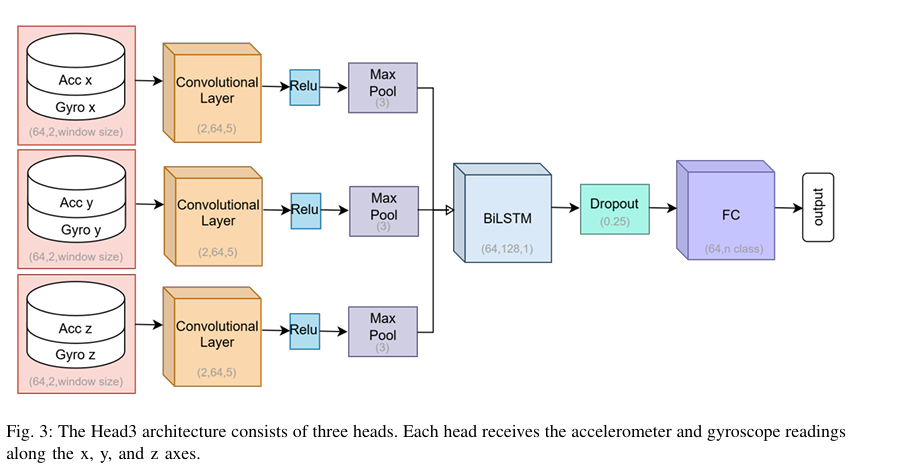

In [ ]:
class InertialClassifier(nn.Module):
    def __init__(self, n_classes=6, hidden=HIDDEN_SIZE, dropout=DROPOUT_RATE):
        super().__init__()

        # Each head processes 2 channels (acc + gyro for that axis)
        def make_head():
            return nn.Sequential(
                nn.Conv1d(2, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.head_x = make_head()
        self.head_y = make_head()
        self.head_z = make_head()

        # After concat: 32 * 3 = 96 channels
        self.bilstm = nn.LSTM(
            input_size=96,
            hidden_size=hidden,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        # x: (B, 6, T)

        # Axis-wise split
        x_axis = torch.stack([x[:, 0, :], x[:, 3, :]], dim=1)  # acc_x, gyro_x → (B,2,T)
        y_axis = torch.stack([x[:, 1, :], x[:, 4, :]], dim=1)  # acc_y, gyro_y
        z_axis = torch.stack([x[:, 2, :], x[:, 5, :]], dim=1)  # acc_z, gyro_z

        # Apply CNN heads
        x_feat = self.head_x(x_axis)   # (B, 32, T//3)
        y_feat = self.head_y(y_axis)
        z_feat = self.head_z(z_axis)

        # Ensure same temporal size
        assert x_feat.shape[2] == y_feat.shape[2] == z_feat.shape[2]

        # Merge along channel dimension
        x = torch.cat([x_feat, y_feat, z_feat], dim=1)  # (B, 96, T//3)

        # Prepare for LSTM
        x = x.permute(0, 2, 1).contiguous()  # (B, T//3, 96)

        out, _ = self.bilstm(x)

        # Temporal aggregation
        x = self.dropout(out[:, -1, :])  # or torch.mean(out, dim=1)

        return self.fc(x)

###4.  TRAINING & EVALUATION UTILITIES

In [ ]:
def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def train_model(X_train, y_train, X_test, y_test,
                label="Baseline", epochs=EPOCHS):
    model     = InertialClassifier().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    loader    = make_loader(X_train, y_train)

    history = {"train_loss": [], "val_acc": []}
    print(f"\n{'─'*50}")
    print(f"  Training: {label}  |  samples={len(X_train)}")
    print(f"{'─'*50}")

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        with torch.no_grad():
            Xt = torch.tensor(X_test).to(DEVICE)
            preds = model(Xt).argmax(dim=1).cpu().numpy()
        acc = accuracy_score(y_test, preds) * 100
        avg_loss = total_loss / len(loader)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%")

    print(f"\n  ✓ Final Accuracy [{label}]: {acc:.2f}%\n")
    return model, history, preds


###5.  VISUALIZATION

In [ ]:
def plot_all_results(histories, final_accs, preds_dict, y_test):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    from matplotlib import gridspec

    os.makedirs("plots", exist_ok=True)

    act_labels = [ACTIVITIES[i+1] for i in range(NUM_CLASSES)]
    colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    names      = list(histories.keys())

    cmap_style = "viridis"   # ✅ same colormap
    vmin, vmax = 0, 100      # ✅ fixed scale

    # ================= COMBINED FIGURE =================
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Neural Inertial Classification — UCI-HAR Benchmark\n"
                 "Baseline vs. Augmentation Techniques",
                 fontsize=15, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── (A) Accuracy ─────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(names, final_accs, color=colors)
    ax1.set_ylim(70, 100)
    ax1.set_title("(A) Accuracy")

    # Save separately
    plt.figure()
    plt.bar(names, final_accs, color=colors)
    plt.title("Accuracy")
    plt.savefig("plots/model_3_accuracy.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ── (B) Improvement ─────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    baseline_acc = final_accs[0]
    improvements = [acc - baseline_acc for acc in final_accs[1:]]
    imp_names    = names[1:]

    ax2.bar(imp_names, improvements)

    # Save separately
    plt.figure()
    plt.bar(imp_names, improvements)
    plt.title("Improvement")
    plt.savefig("plots/model_3_improvement.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ── (C) Training loss ───────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    for (name, hist), color in zip(histories.items(), colors):
        ax3.plot(hist["train_loss"], label=name)

    # Save separately
    plt.figure()
    for (name, hist) in histories.items():
        plt.plot(hist["train_loss"], label=name)
    plt.legend()
    plt.title("Training Loss")
    plt.savefig("plots/model_3_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ── (D) Validation accuracy ─────────────
    ax4 = fig.add_subplot(gs[1, 1])
    for (name, hist), color in zip(histories.items(), colors):
        ax4.plot(hist["val_acc"], label=name)

    # Save separately
    plt.figure()
    for (name, hist) in histories.items():
        plt.plot(hist["val_acc"], label=name)
    plt.legend()
    plt.title("Validation Accuracy")
    plt.savefig("plots/model_3_val_acc.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ── (E) Confusion Matrix Baseline ───────
    ax5 = fig.add_subplot(gs[2, 0])
    cm_base = confusion_matrix(y_test, preds_dict["Baseline"])
    cm_norm = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_norm, annot=True, fmt=".1f",
                cmap=cmap_style, vmin=vmin, vmax=vmax,
                xticklabels=act_labels, yticklabels=act_labels,
                ax=ax5)

    # Save separately
    plt.figure()
    sns.heatmap(cm_norm, annot=True, fmt=".1f",
                cmap=cmap_style, vmin=vmin, vmax=vmax,
                xticklabels=act_labels, yticklabels=act_labels)
    plt.title("Confusion Matrix — Baseline")
    plt.savefig("plots/model_3_cm_baseline.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ── (F) Confusion Matrix Best ───────────
    best_name = names[1 + np.argmax(improvements)]
    ax6 = fig.add_subplot(gs[2, 1])

    cm_best = confusion_matrix(y_test, preds_dict[best_name])
    cm_norm2 = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_norm2, annot=True, fmt=".1f",
                cmap=cmap_style, vmin=vmin, vmax=vmax,
                xticklabels=act_labels, yticklabels=act_labels,
                ax=ax6)

    # Save separately
    plt.figure()
    sns.heatmap(cm_norm2, annot=True, fmt=".1f",
                cmap=cmap_style, vmin=vmin, vmax=vmax,
                xticklabels=act_labels, yticklabels=act_labels)
    plt.title(f"Confusion Matrix — {best_name}")
    plt.savefig("plots/model_3_cm_best.png", dpi=300, bbox_inches="tight")
    plt.close()

    # Save combined
    plt.savefig("plots/model_3_results_comparison.png", dpi=150, bbox_inches="tight")

    print("✅ All plots saved with prefix 'model_3_' in /plots folder")
    plt.show()

###6.  SUMMARY TABLE

In [ ]:
def print_summary(names, final_accs, train_sizes):
    baseline = final_accs[0]
    print("\n" + "="*65)
    print(f"  {'Technique':<25} {'Train Samples':>14} {'Accuracy':>10} {'Δ Baseline':>12}")
    print("="*65)
    for name, acc, ts in zip(names, final_accs, train_sizes):
        delta = acc - baseline
        flag  = " ▲" if delta > 0 else ("  " if delta == 0 else " ▼")
        print(f"  {name:<25} {ts:>14,} {acc:>9.2f}% {delta:>+10.2f}%{flag}")
    print("="*65)
    best_idx = int(np.argmax(final_accs))
    print(f"\n  Best technique : {names[best_idx]}  ({final_accs[best_idx]:.2f}%)")
    print(f"  Max improvement: {final_accs[best_idx] - baseline:+.2f}% over baseline")
    print("="*65 + "\n")


### Main

  Neural Inertial Classification — UCI-HAR Demo
model 3
  Baseline vs. Augmentation Comparison

Download complete.

Loading signals …
Train: (7352, 6, 50)  |  Test: (2947, 6, 50)
Classes: [0 1 2 3 4 5]


──────────────────────────────────────────────────
  Training: Baseline  |  samples=7352
──────────────────────────────────────────────────
  Epoch   1/20 | Loss: 1.3345 | Val Acc: 40.48%
  Epoch   5/20 | Loss: 0.6909 | Val Acc: 59.11%
  Epoch  10/20 | Loss: 0.6029 | Val Acc: 64.85%
  Epoch  15/20 | Loss: 0.5732 | Val Acc: 67.70%
  Epoch  20/20 | Loss: 0.5544 | Val Acc: 68.44%

  ✓ Final Accuracy [Baseline]: 68.44%


──────────────────────────────────────────────────
  Training: Rotation (all ax)  |  samples=29408
──────────────────────────────────────────────────
  Epoch   1/20 | Loss: 1.0154 | Val Acc: 59.25%
  Epoch   5/20 | Loss: 0.5797 | Val Acc: 70.27%
  Epoch  10/20 | Loss: 0.4966 | Val Acc: 78.55%
  Epoch  15/20 | Loss: 0.3963 | Val Acc: 83.37%
  Epoch  20/20 | Loss: 0.3388 | V

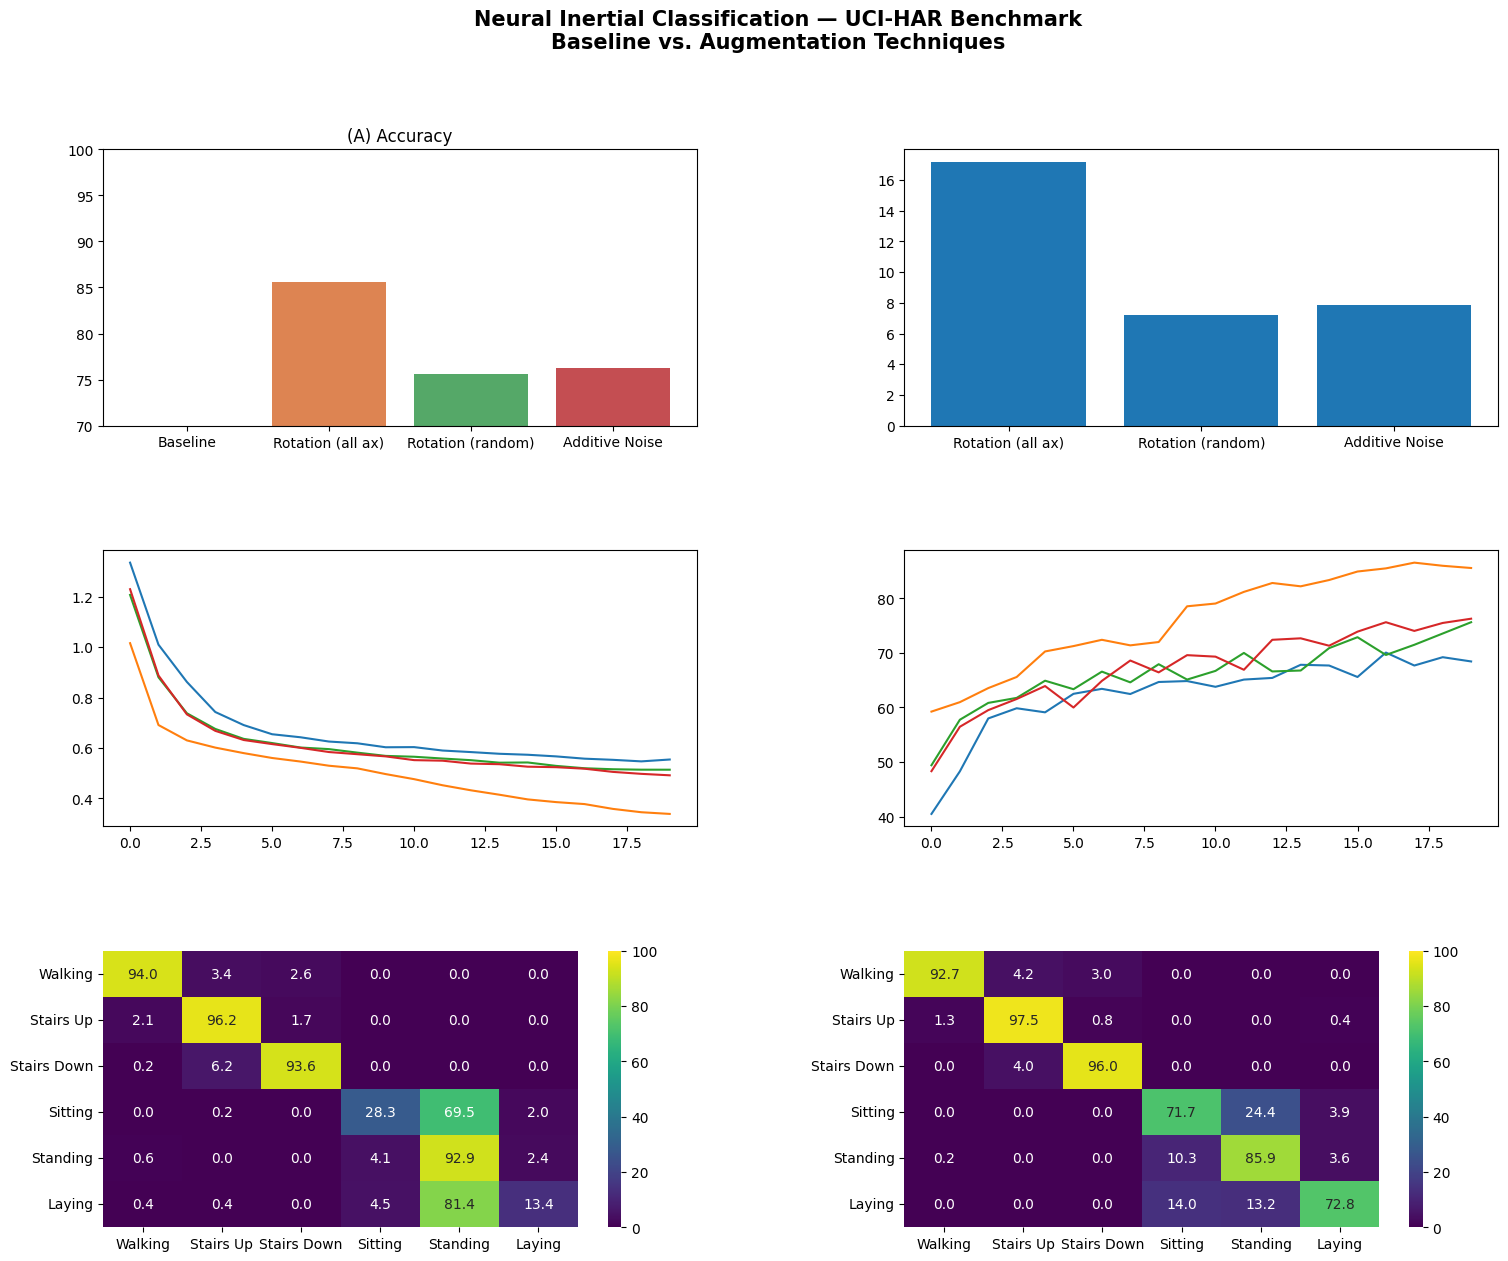


✓ Demo complete!


In [ ]:
def main():
    print("=" * 65)
    print("  Neural Inertial Classification — UCI-HAR Demo")
    print("model 3")
    print("  Baseline vs. Augmentation Comparison")
    print("=" * 65 + "\n")

    # Load data
    X_train_raw, X_test, y_train_raw, y_test = load_uci_har()

    # Define experiments
    experiments = {
        "Baseline":          (X_train_raw.copy(), y_train_raw.copy()),
        "Rotation (all ax)": augment_rotation(X_train_raw, y_train_raw, mode="all_axes"),
        "Rotation (random)": augment_rotation(X_train_raw, y_train_raw, mode="random"),
        "Additive Noise":    augment_noise(X_train_raw,    y_train_raw, sigma=0.05),
    }

    histories   = {}
    final_accs  = []
    preds_dict  = {}
    train_sizes = []

    for name, (X_tr, y_tr) in experiments.items():
        model, hist, preds = train_model(X_tr, y_tr, X_test, y_test, label=name)
        histories[name]  = hist
        final_accs.append(hist["val_acc"][-1])
        preds_dict[name] = preds
        train_sizes.append(len(X_tr))

    # Summary
    names = list(experiments.keys())
    print_summary(names, final_accs, train_sizes)

    # Per-class report for best model
    best_idx  = int(np.argmax(final_accs))
    best_name = names[best_idx]
    act_labels = [ACTIVITIES[i+1] for i in range(NUM_CLASSES)]
    print(f"  Classification Report — {best_name}\n")
    print(classification_report(y_test, preds_dict[best_name],
                                target_names=act_labels))

    # Plots
    plot_all_results(histories, final_accs, preds_dict, y_test)

    print("\n✓ Demo complete!")


if __name__ == "__main__":
    main()